In [20]:
# Install required packages

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('default')
sns.set_palette("husl")

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
Keras version: 3.11.3
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
# Suppress TensorFlow and XLA warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import logging
logging.getLogger('tensorflow').setLevel(logging.FATAL)
logging.getLogger('absl').setLevel(logging.ERROR)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from IPython import display
display.clear_output()

print("⚙️ Warning messages suppressed. Continuing with clean output...")

⚙️ Warning messages suppressed. Continuing with clean output...


In [23]:
TRAIN_DIR = "./data/archive/chest_xray/train"
TEST_DIR = "./data/archive/chest_xray/test"
VAL_DIR = "./data/archive/chest_xray/val"  

IMG_SIZE = (224, 224)  
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001
PATIENCE = 10  

MODEL_SAVE_PATH = "/content/models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("Configuration completed!")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

Configuration completed!
Image size: (224, 224)
Batch size: 32
Epochs: 100
Learning rate: 0.001



=== Training Set Exploration ===
   NORMAL: 1341 images
   PNEUMONIA: 3875 images
   Total: 5216 images


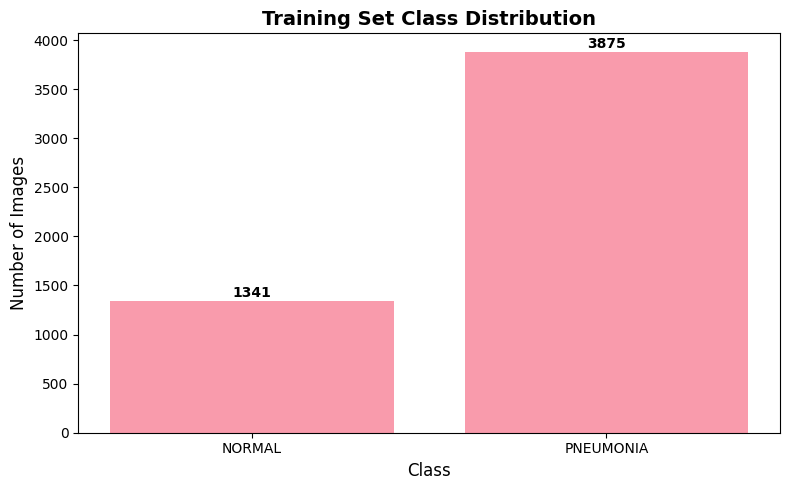


=== Test Set Exploration ===
   NORMAL: 234 images
   PNEUMONIA: 390 images
   Total: 624 images


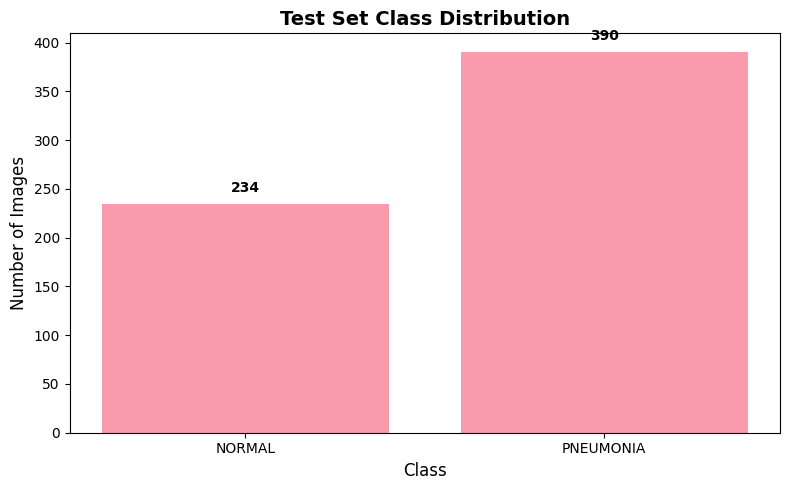


=== Validation Set Exploration ===
   NORMAL: 8 images
   PNEUMONIA: 8 images
   Total: 16 images


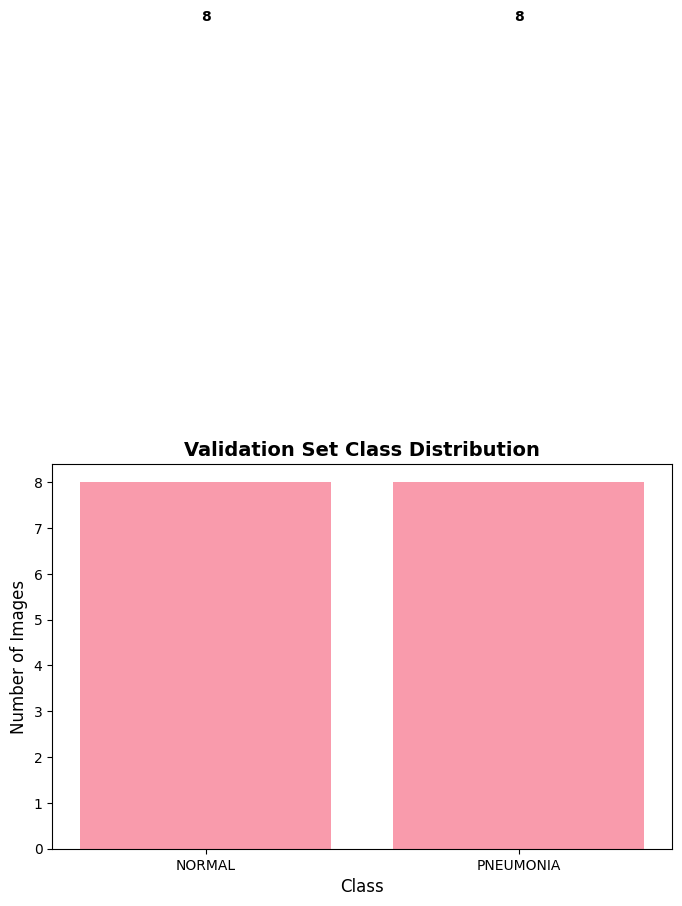

In [24]:
def explore_dataset(base_dir, title="Dataset"):
    print(f"\n=== {title} Exploration ===")
    
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return None
    
    class_counts = {}
    total_images = 0
    
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            count = len(image_files)
            class_counts[class_name] = count
            total_images += count
            print(f"   {class_name}: {count} images")
    
    print(f"   Total: {total_images} images")
    
    if class_counts:
        plt.figure(figsize=(8, 5))
        classes = list(class_counts.keys())
        counts = list(class_counts.values())
        
        bars = plt.bar(classes, counts, alpha=0.7)
        plt.title(f'{title} Class Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Class', fontsize=12)
        plt.ylabel('Number of Images', fontsize=12)
        
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    str(count), ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    return class_counts

train_counts = explore_dataset(TRAIN_DIR, "Training Set")
test_counts = explore_dataset(TEST_DIR, "Test Set")

if os.path.exists(VAL_DIR):
    val_counts = explore_dataset(VAL_DIR, "Validation Set")
else:
    print("No separate validation directory found. Will create train/val split.")
    val_counts = None

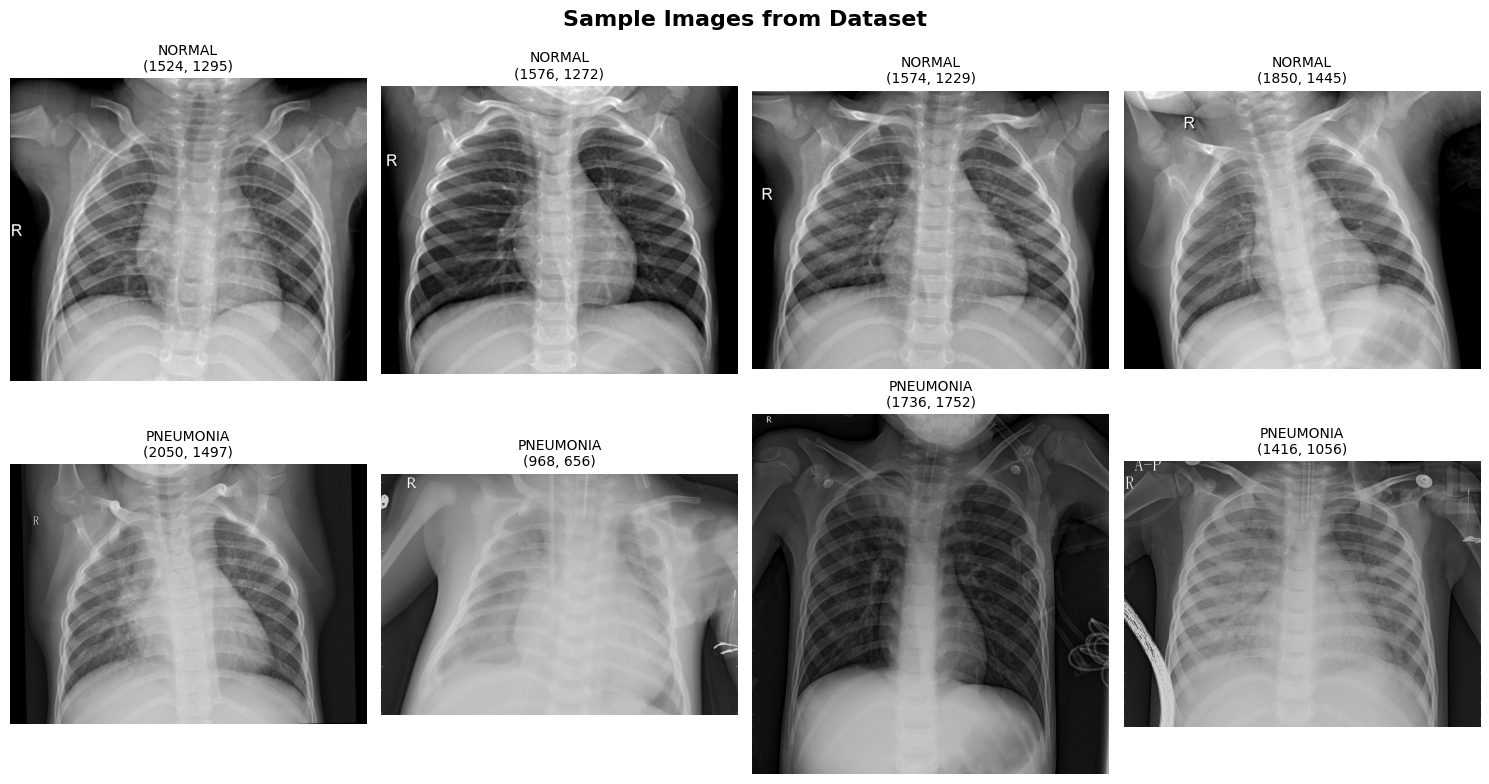

In [25]:
def display_sample_images(base_dir, num_samples=4):
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return
    
    classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 4*len(classes)))
    if len(classes) == 1:
        axes = [axes]
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(base_dir, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        sample_files = np.random.choice(image_files, 
                                       min(num_samples, len(image_files)), 
                                       replace=False)
        
        for j, img_file in enumerate(sample_files):
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path)
            
            if len(classes) > 1:
                ax = axes[i][j]
            else:
                ax = axes[j]
                
            ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
            ax.set_title(f'{class_name}\n{img.size}', fontsize=10)
            ax.axis('off')
    
    plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

display_sample_images(TRAIN_DIR, num_samples=4)

In [26]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,           
    rotation_range=20,           
    width_shift_range=0.2,    
    height_shift_range=0.2,   
    shear_range=0.2,           
    zoom_range=0.2,           
    horizontal_flip=True,      
    fill_mode='nearest',        
    validation_split=0.2 if not os.path.exists(VAL_DIR) else 0.0
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

if os.path.exists(VAL_DIR):
    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=42
    )
    
    val_generator = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False,
        seed=42
    )
else:
    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='training',
        shuffle=True,
        seed=42
    )
    
    val_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        shuffle=False,
        seed=42
    )

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=42
)

print("Data generators created successfully!")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Data generators created successfully!
Training samples: 5216
Validation samples: 16
Test samples: 624
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


In [27]:
def create_custom_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

custom_cnn = create_custom_cnn(input_shape=(*IMG_SIZE, 3))

custom_cnn.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Custom CNN Model Architecture:")
custom_cnn.summary()

Custom CNN Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,308,321 (4.99 MB)

 Trainable params: 1,306,337 (4.98 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [28]:
# Define feature extraction function for SVM
def extract_raw_features(img):
    if len(img.shape) == 3 and img.shape[2] == 3:
        gray = np.mean(img, axis=2)
    else:
        gray = img
        
    features = []
    
    features.append(np.mean(gray))  
    features.append(np.std(gray))  
    features.append(np.min(gray))  
    features.append(np.max(gray))   
    
    hist, _ = np.histogram(gray, bins=10, range=(0, 1))
    features.extend(hist / np.sum(hist)) 
    
    edges_h = np.abs(gray[:, 1:] - gray[:, :-1]).mean()
    edges_v = np.abs(gray[1:, :] - gray[:-1, :]).mean()
    features.append(edges_h)
    features.append(edges_v)
    
    h, w = gray.shape
    features.append(np.mean(gray[:h//2, :w//2]))
    features.append(np.mean(gray[:h//2, w//2:]))
    features.append(np.mean(gray[h//2:, :w//2]))
    features.append(np.mean(gray[h//2:, w//2:]))
    
    return np.array(features)

print("SVM Feature Extraction:")

SVM Feature Extraction:


In [29]:
# Training callbacks
def get_callbacks(model_name):
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(MODEL_SAVE_PATH, f'{model_name}_best.h5'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    return callbacks

def train_model(model, model_name, epochs=EPOCHS):
    print(f"\nTraining {model_name}...")
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        epochs=epochs,
        validation_data=val_generator,
        validation_steps=val_generator.samples // BATCH_SIZE,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    
    print(f"{model_name} training completed!")
    return history

print("Training setup completed!")

Training setup completed!


In [30]:
# SVM Implementation
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

print("\n🔍 Training SVM model (Support Vector Machine)...")
print("This is a true machine learning model, not a neural network.")

def extract_features_from_generator(generator, verbose=1):
    features = []
    labels = []
    batch_size = generator.batch_size
    steps = generator.samples // batch_size
    
    if verbose:
        print(f"Extracting features from {generator.samples} images...")
    
    generator.reset()
    for i in range(steps):
        if verbose and i % 10 == 0:
            print(f"  Processing batch {i+1}/{steps}")
            
        x_batch, y_batch = next(generator)
        batch_features = [extract_raw_features(img) for img in x_batch]
        features.extend(batch_features)
        labels.extend(y_batch)
    
    if generator.samples % batch_size != 0:
        x_batch, y_batch = next(generator)
        batch_size_rem = generator.samples % batch_size
        batch_features = [extract_raw_features(img) for img in x_batch[:batch_size_rem]]
        features.extend(batch_features)
        labels.extend(y_batch[:batch_size_rem])
    
    return np.array(features), np.array(labels)

print("Step 1: Extracting features from training data...")
start_time = time.time()
train_features, train_labels = extract_features_from_generator(train_generator)
print(f"Training features shape: {train_features.shape}, labels shape: {train_labels.shape}")
print(f"Feature extraction for training completed in {time.time() - start_time:.2f} seconds")

print("\nStep 2: Extracting features from validation data...")
start_time = time.time()
val_features, val_labels = extract_features_from_generator(val_generator)
print(f"Validation features shape: {val_features.shape}, labels shape: {val_labels.shape}")
print(f"Feature extraction for validation completed in {time.time() - start_time:.2f} seconds")

print("\nStep 3: Extracting features from test data...")
start_time = time.time()
test_features, test_labels = extract_features_from_generator(test_generator)
print(f"Test features shape: {test_features.shape}, labels shape: {test_labels.shape}")
print(f"Feature extraction for test completed in {time.time() - start_time:.2f} seconds")

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  
    ('svm', SVC(kernel='rbf', probability=True, C=1.0, gamma='scale'))
])

print("\nStep 4: Training SVM model...")
start_time = time.time()
svm_pipeline.fit(train_features, train_labels)
print(f"SVM training completed in {time.time() - start_time:.2f} seconds")

print("\nStep 5: Evaluating SVM on validation data...")
val_pred = svm_pipeline.predict(val_features)
val_accuracy = accuracy_score(val_labels, val_pred)
val_precision = precision_score(val_labels, val_pred)
val_recall = recall_score(val_labels, val_pred)
val_f1 = f1_score(val_labels, val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")
print(f"Validation F1-Score: {val_f1:.4f}")

import joblib
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
joblib.dump(svm_pipeline, os.path.join(MODEL_SAVE_PATH, 'svm_model.joblib'))
print(f"\nSVM model saved to {os.path.join(MODEL_SAVE_PATH, 'svm_model.joblib')}")


🔍 Training SVM model (Support Vector Machine)...
This is a true machine learning model, not a neural network.
Step 1: Extracting features from training data...
Extracting features from 5216 images...
  Processing batch 1/163
  Processing batch 11/163
  Processing batch 21/163
  Processing batch 31/163
  Processing batch 41/163
  Processing batch 51/163
  Processing batch 61/163
  Processing batch 71/163
  Processing batch 81/163
  Processing batch 91/163
  Processing batch 101/163
  Processing batch 111/163
  Processing batch 121/163
  Processing batch 131/163
  Processing batch 141/163
  Processing batch 151/163
  Processing batch 161/163
Training features shape: (5216, 20), labels shape: (5216,)
Feature extraction for training completed in 59.87 seconds

Step 2: Extracting features from validation data...
Extracting features from 16 images...
Validation features shape: (16, 20), labels shape: (16,)
Feature extraction for validation completed in 0.11 seconds

Step 3: Extracting featu

In [31]:
# Train custom CNN model
custom_cnn_history = train_model(custom_cnn, "Custom_CNN", epochs=EPOCHS)


Training Custom_CNN...
Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.7667 - loss: 0.5347 - precision: 0.8963 - recall: 0.7750
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /content/models/Custom_CNN_best.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 319ms/step - accuracy: 0.8271 - loss: 0.4064 - precision: 0.9065 - recall: 0.8555 - val_accuracy: 0.5000 - val_loss: 3.1663 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.8711 - loss: 0.3105 - precision: 0.9055 - recall: 0.9248
Epoch 2: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 317ms/step - accuracy: 0.8765 - loss: 0.3010 - precision: 0.9108 - recall: 0.9244 - val_accuracy: 0.5000 - val_loss: 3.7835 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.8922 - loss: 0.2639 - precision: 0.9174 - recall

In [32]:
def evaluate_model_comprehensive(model, model_name, test_generator):
    print(f"\nEvaluating {model_name}...")
    
    test_generator.reset()
    
    predictions = model.predict(test_generator, verbose=1)
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_true = test_generator.classes
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    recall = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    test_loss, test_acc, test_precision, test_recall = model.evaluate(
        test_generator, verbose=0
    )
    
    results = {
        'Model': model_name,
        'Test_Loss': round(test_loss, 4),
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall (Sensitivity)': round(recall, 4),
        'Specificity': round(specificity, 4),
        'F1-Score': round(f1, 4)
    }
    
    return results, y_true, y_pred, predictions

custom_results, y_true_custom, y_pred_custom, pred_probs_custom = evaluate_model_comprehensive(
    custom_cnn, "Custom CNN", test_generator
)

print("\nEvaluating SVM model on test data...")
svm_pred = svm_pipeline.predict(test_features)
svm_pred_proba = svm_pipeline.predict_proba(test_features)[:, 1]

svm_accuracy = accuracy_score(test_labels, svm_pred)
svm_precision = precision_score(test_labels, svm_pred)
svm_recall = recall_score(test_labels, svm_pred)
svm_f1 = f1_score(test_labels, svm_pred)

cm = confusion_matrix(test_labels, svm_pred)
tn, fp, fn, tp = cm.ravel()
svm_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

svm_results = {
    'Model': 'SVM',
    'Test_Loss': 0.0,  
    'Accuracy': round(svm_accuracy, 4),
    'Precision': round(svm_precision, 4),
    'Recall (Sensitivity)': round(svm_recall, 4),
    'Specificity': round(svm_specificity, 4),
    'F1-Score': round(svm_f1, 4)
}

y_true_svm = test_labels
y_pred_svm = svm_pred
pred_probs_svm = svm_pred_proba

all_results = [custom_results, svm_results]
results_df = pd.DataFrame(all_results)

print("\n📋 Model Performance Comparison:")
print("=" * 80)
print(results_df.to_string(index=False))

results_df.to_csv(os.path.join(MODEL_SAVE_PATH, 'model_comparison_results.csv'), index=False)
print(f"\nResults saved!")


Evaluating Custom CNN...
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step

Evaluating SVM model on test data...

📋 Model Performance Comparison:
     Model  Test_Loss  Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-Score
Custom CNN     0.3174    0.8782     0.9198                0.8821       0.8718    0.9005
       SVM     0.0000    0.6571     0.7211                0.7359       0.5256    0.7284

Results saved!


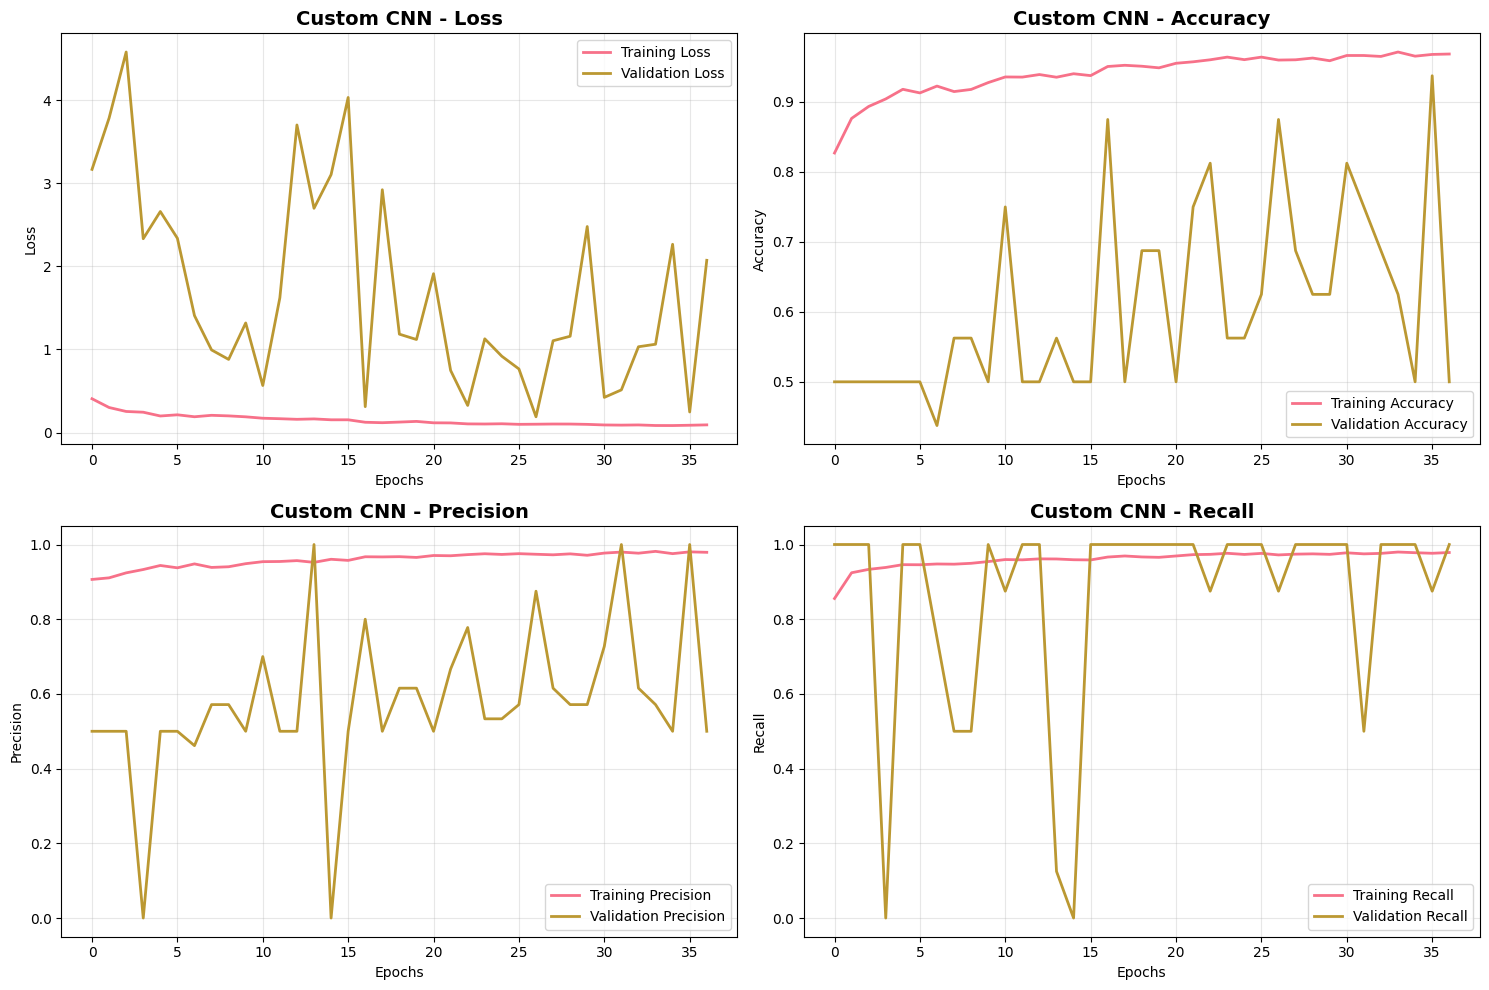


SVM Model Performance:
Test Accuracy: 0.6571
Test Precision: 0.7211
Test Recall: 0.7359
Test F1-Score: 0.7284
Test Specificity: 0.5256


In [33]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
    axes[1, 0].set_title(f'{model_name} - Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
    axes[1, 1].set_title(f'{model_name} - Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(custom_cnn_history, "Custom CNN")
print("\nSVM Model Performance:")
print(f"Test Accuracy: {svm_accuracy:.4f}")
print(f"Test Precision: {svm_precision:.4f}")
print(f"Test Recall: {svm_recall:.4f}")
print(f"Test F1-Score: {svm_f1:.4f}")
print(f"Test Specificity: {svm_specificity:.4f}")

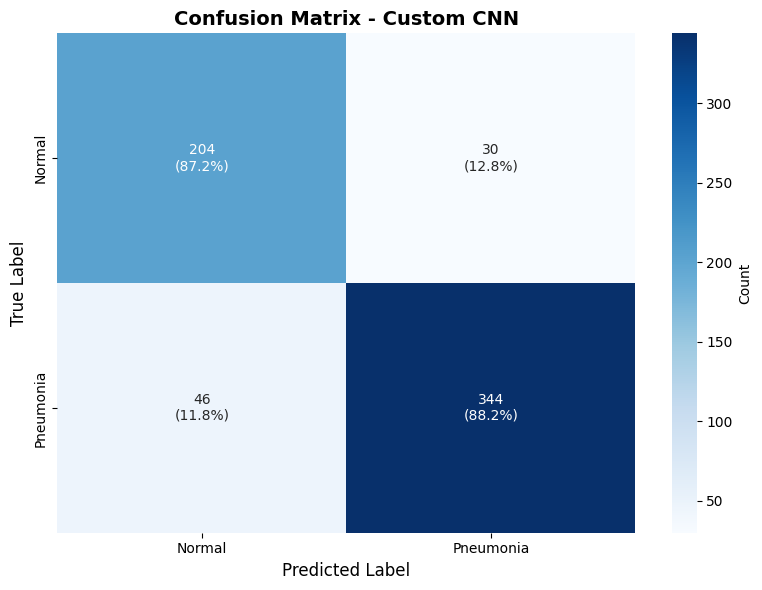


Classification Report - Custom CNN
              precision    recall  f1-score   support

      Normal     0.8160    0.8718    0.8430       234
   Pneumonia     0.9198    0.8821    0.9005       390

    accuracy                         0.8782       624
   macro avg     0.8679    0.8769    0.8717       624
weighted avg     0.8809    0.8782    0.8789       624



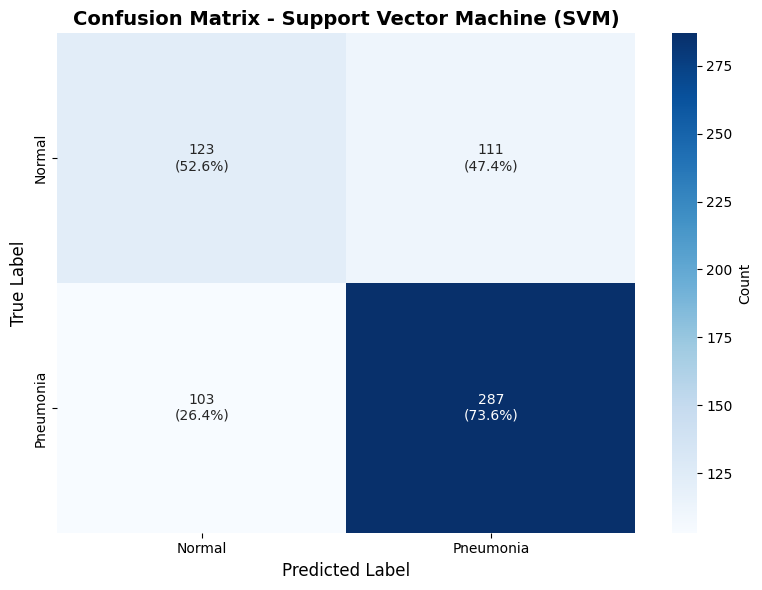


Classification Report - Support Vector Machine (SVM)
              precision    recall  f1-score   support

      Normal     0.5442    0.5256    0.5348       234
   Pneumonia     0.7211    0.7359    0.7284       390

    accuracy                         0.6571       624
   macro avg     0.6327    0.6308    0.6316       624
weighted avg     0.6548    0.6571    0.6558       624



In [34]:
def plot_confusion_matrix(y_true, y_pred, model_name, class_names=['Normal', 'Pneumonia']):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    plt.figure(figsize=(8, 6))
    
    annotations = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
    
    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

def print_classification_report(y_true, y_pred, model_name, class_names=['Normal', 'Pneumonia']):
    print(f"\nClassification Report - {model_name}")
    print("=" * 60)
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)

plot_confusion_matrix(y_true_custom, y_pred_custom, "Custom CNN")
print_classification_report(y_true_custom, y_pred_custom, "Custom CNN")

plot_confusion_matrix(y_true_svm, y_pred_svm, "Support Vector Machine (SVM)")
print_classification_report(y_true_svm, y_pred_svm, "Support Vector Machine (SVM)")

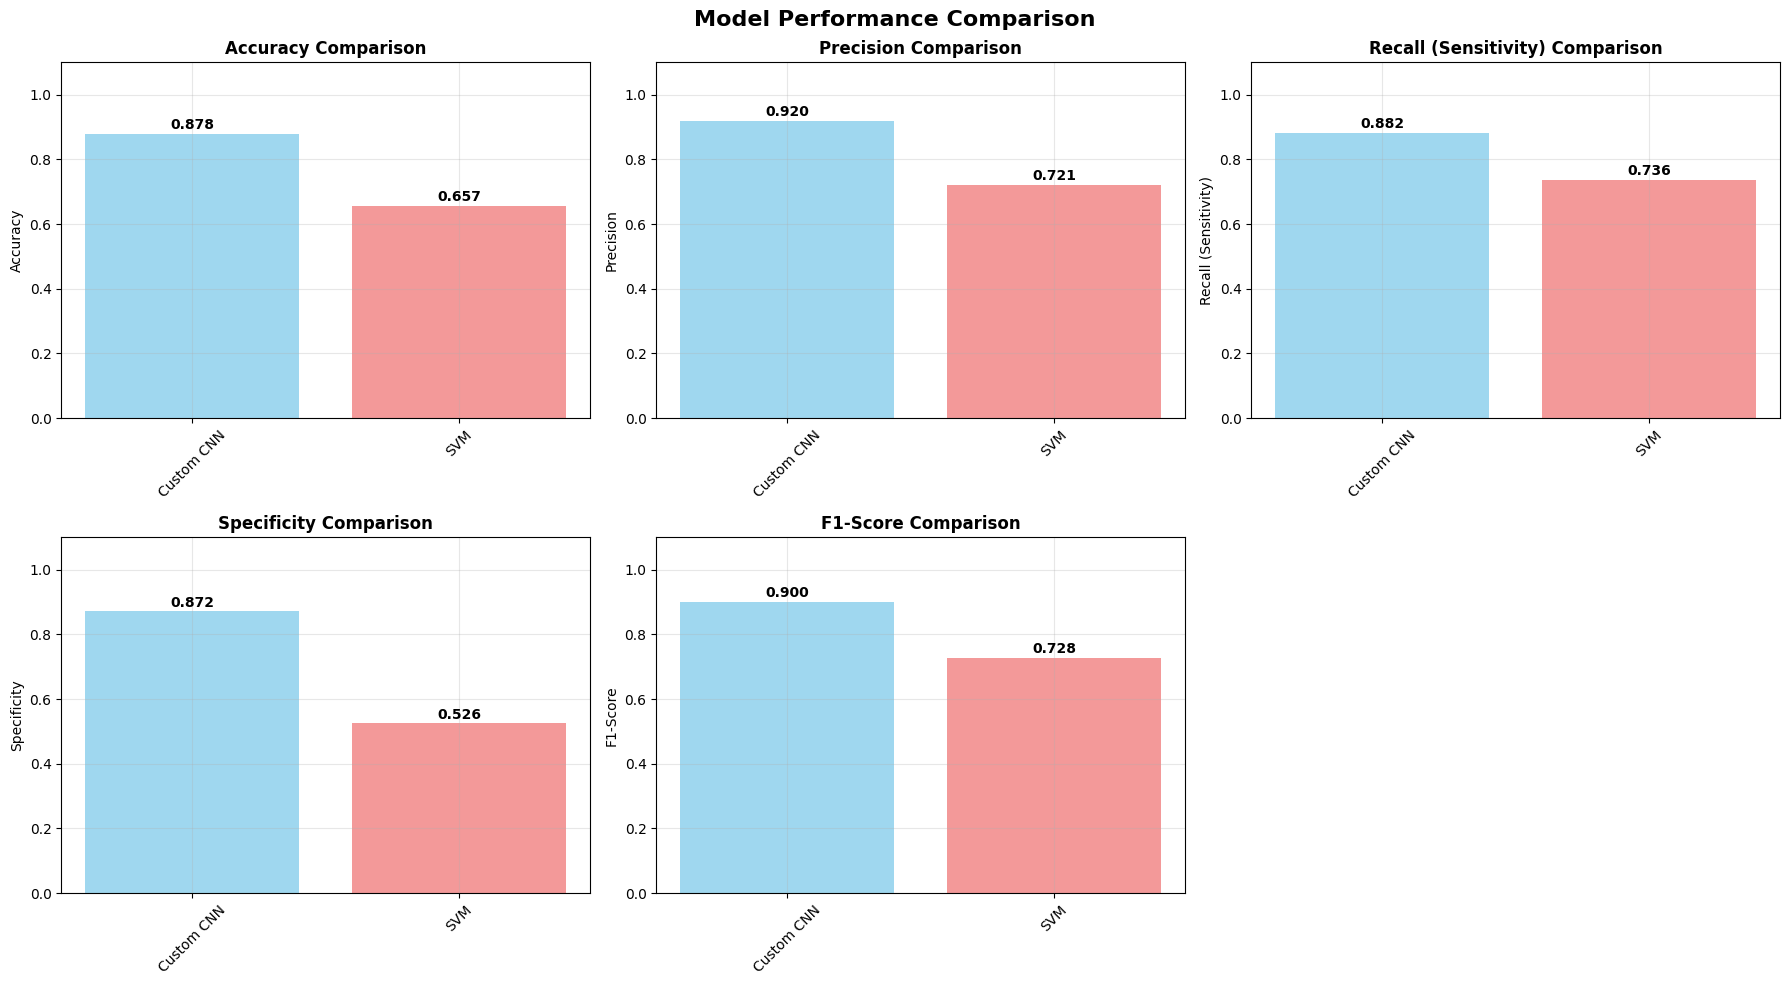


BEST PERFORMING MODEL: Custom CNN
Accuracy: 0.8782
Precision: 0.9198
Recall: 0.8821
Specificity: 0.8718
F1-Score: 0.9005


In [35]:
def plot_model_comparison(results_df):
    metrics = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1-Score']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        models = results_df['Model'].values
        values = results_df[metric].values
        
        bars = ax.bar(models, values, alpha=0.8, color=['skyblue', 'lightcoral'])
        
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    axes[5].remove()
    
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_model_comparison(results_df)

best_model_idx = results_df['F1-Score'].idxmax()
best_model = results_df.loc[best_model_idx]

print(f"\nBEST PERFORMING MODEL: {best_model['Model']}")
print("=" * 50)
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall (Sensitivity)']:.4f}")
print(f"Specificity: {best_model['Specificity']:.4f}")
print(f"F1-Score: {best_model['F1-Score']:.4f}")

In [36]:
print("\n" + "="*70)
print("EXERCISE-2 COMPLETION SUMMARY")
print("="*70)

print("\nCOMPLETED REQUIREMENTS:")
print("   Chest X-Ray dataset loaded and preprocessed")
print("   Data augmentation implemented")
print("   Custom CNN architecture designed and trained")
print("   SVM classifier with statistical features implemented")
print("   Comprehensive evaluation with all metrics")
print("   Training history visualization")
print("   Confusion matrices and classification reports")
print("   Model performance comparison")
print("   Best model identification")

print("\nKEY FINDINGS:")
if 'best_model' in locals():
    print(f"   Best Model: {best_model['Model']}")
    print(f"   Best Accuracy: {best_model['Accuracy']:.4f}")
    print(f"   Best F1-Score: {best_model['F1-Score']:.4f}")

print("\nMODELS IMPLEMENTED:")
print("   1. Custom CNN: Multi-layer with batch normalization")
print("   2. Support Vector Machine (SVM): Classical machine learning with feature extraction")

print("\nFILES GENERATED:")
print(f"   Results: {MODEL_SAVE_PATH}/model_comparison_results.csv")
print(f"   Models: {MODEL_SAVE_PATH}/Custom_CNN_best.h5")
print(f"   Models: {MODEL_SAVE_PATH}/svm_model.joblib")


EXERCISE-2 COMPLETION SUMMARY

COMPLETED REQUIREMENTS:
   Chest X-Ray dataset loaded and preprocessed
   Data augmentation implemented
   Custom CNN architecture designed and trained
   SVM classifier with statistical features implemented
   Comprehensive evaluation with all metrics
   Training history visualization
   Confusion matrices and classification reports
   Model performance comparison
   Best model identification

KEY FINDINGS:
   Best Model: Custom CNN
   Best Accuracy: 0.8782
   Best F1-Score: 0.9005

MODELS IMPLEMENTED:
   1. Custom CNN: Multi-layer with batch normalization
   2. Support Vector Machine (SVM): Classical machine learning with feature extraction

FILES GENERATED:
   Results: /content/models/model_comparison_results.csv
   Models: /content/models/Custom_CNN_best.h5
   Models: /content/models/svm_model.joblib
